In [1]:
!pip install opendatasets --quiet

In [2]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: sunillimbu10
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:49<00:00, 14.9MB/s]


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import os

In [27]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device}")

Using cuda


In [28]:
image_path = []
labels = []
splits = []

for split in os.listdir("/content/animal-faces/afhq"):
    split_path = f"/content/animal-faces/afhq/{split}"
    for label in os.listdir(split_path):
        label_path = f"{split_path}/{label}"
        for k in os.listdir(label_path):
            image_path.append(f"{label_path}/{k}")
            labels.append(label)
            splits.append(split)

df = pd.DataFrame({"image_path": image_path, "labels": labels, "split": splits})
df.head()

,image_path,labels,split
0,/content/animal-faces/afhq/val/cat/flickr_cat_...,cat,val
1,/content/animal-faces/afhq/val/cat/flickr_cat_...,cat,val
2,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat,val
3,/content/animal-faces/afhq/val/cat/flickr_cat_...,cat,val
4,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat,val


In [29]:
df.shape

(16130, 3)

In [30]:
# split train and validation dataset
train=df[df['split']=='train']
val=df[df['split']=='val']

In [31]:
train = train.drop('split',axis=1)
val_data = val.drop('split',axis=1)

In [33]:
print(train.shape,val_data.shape)

(14630, 2) (1500, 2)


In [34]:
# spit test set
from sklearn.model_selection import train_test_split
train_data,test_data=train_test_split(train,test_size=0.10,stratify=train["labels"],random_state=42)

In [36]:
# Encode the labels
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
train_data['labels']=le.fit_transform(train_data['labels'])
val_data['labels']=le.transform(val_data['labels'])
test_data['labels']=le.transform(test_data['labels'])

In [37]:
test_data.head()

,image_path,labels
11211,/content/animal-faces/afhq/train/dog/flickr_do...,1
5340,/content/animal-faces/afhq/train/cat/pixabay_c...,0
15202,/content/animal-faces/afhq/train/wild/flickr_w...,2
14176,/content/animal-faces/afhq/train/wild/flickr_w...,2
4482,/content/animal-faces/afhq/train/cat/pixabay_c...,0


In [38]:
# Create transforms
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [39]:
# Create Custom Dataset
from torch.utils.data import Dataset
from PIL import Image
class CustomImageDataset(Dataset):
    def __init__(self,df,transform=None):
      self.df=df
      self.transform=transform
      self.labels=torch.tensor(df['labels'].values,dtype=torch.long)

    def __len__(self):
      return len(self.df)

    def __getitem__(self,index):

      image_path=self.df.iloc[index,0]

      # convert to rgb
      image=Image.open(image_path).convert('RGB')

      # transfrom
      if self.transform:
        image=self.transform(image)



      return image,self.labels[index]



In [40]:
train_dataset=CustomImageDataset(train_data,transform=train_transform)
val_dataset=CustomImageDataset(val_data,transform=val_test_transform)
test_dataset=CustomImageDataset(test_data,transform=val_test_transform)

In [41]:
# Crete a custom dataloader
from torch.utils.data import DataLoader
train_dataloader=DataLoader(train_dataset,batch_size=32,shuffle=True)
val_dataloader=DataLoader(val_dataset,batch_size=32,shuffle=False)
test_dataloader=DataLoader(test_dataset,batch_size=32,shuffle=False)

In [17]:
# Fetch the pretrained Model
from torchvision.models import vgg16, VGG16_Weights

model = vgg16(weights=VGG16_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 186MB/s]


In [42]:
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [19]:
# freez features
for parameter in model.features.parameters():
  parameter.requires_grad=False

In [20]:
# Define classifier
import torch.nn as nn
model.classifier=nn.Sequential(
     nn.Linear(25088,1024),
     nn.ReLU(),
     nn.Dropout(p=0.5),

     nn.Linear(1024,512),
     nn.ReLU(),
     nn.Dropout(p=0.5),

     nn.Linear(512,3)

)

In [21]:
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [22]:
model=model.to(device)

In [23]:
learning_rate=0.0001
epochs=10

In [24]:
loss_fun=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.classifier.parameters(),lr=learning_rate,weight_decay=1e-4)

In [43]:
train_loss_graph = []
val_loss_graph   = []
train_acc_graph  = []
val_acc_graph    = []

for epoch in range(epochs):
    avg_train_loss = 0
    avg_train_acc  = 0
    avg_val_loss   = 0
    avg_val_acc    = 0

    model.train()
    for inputs, labels in train_dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        pred = model(inputs)
        train_loss = loss_fun(pred, labels)

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        avg_train_loss += train_loss.item()
        avg_train_acc  += (torch.argmax(pred, axis=1) == labels).sum().item()

    model.eval()
    with torch.no_grad():
        for images, labels in val_dataloader:
            images = images.to(device)
            labels = labels.to(device)

            pred     = model(images)
            val_loss = loss_fun(pred, labels)

            avg_val_loss += val_loss.item()
            avg_val_acc  += (torch.argmax(pred, axis=1) == labels).sum().item()


    avg_train_loss /= len(train_dataloader)
    avg_train_acc  /= len(train_dataset)
    avg_val_loss   /= len(val_dataloader)
    avg_val_acc    /= len(val_dataset)

    train_loss_graph.append(avg_train_loss)
    val_loss_graph.append(avg_val_loss)
    train_acc_graph.append(avg_train_acc)
    val_acc_graph.append(avg_val_acc)


    print(f"Epoch {epoch+1} | train_loss: {avg_train_loss:.4f} | val_loss: {avg_val_loss:.4f} | train_acc: {avg_train_acc:.4f} | val_acc: {avg_val_acc:.4f}")

Epoch 1 | train_loss: 0.0072 | val_loss: 0.0234 | train_acc: 0.9982 | val_acc: 0.9967
Epoch 2 | train_loss: 0.0117 | val_loss: 0.0255 | train_acc: 0.9975 | val_acc: 0.9973
Epoch 3 | train_loss: 0.0090 | val_loss: 0.0263 | train_acc: 0.9975 | val_acc: 0.9973
Epoch 4 | train_loss: 0.0074 | val_loss: 0.0214 | train_acc: 0.9980 | val_acc: 0.9973
Epoch 5 | train_loss: 0.0066 | val_loss: 0.0214 | train_acc: 0.9981 | val_acc: 0.9980
Epoch 6 | train_loss: 0.0076 | val_loss: 0.0248 | train_acc: 0.9980 | val_acc: 0.9980
Epoch 7 | train_loss: 0.0067 | val_loss: 0.0302 | train_acc: 0.9981 | val_acc: 0.9973
Epoch 8 | train_loss: 0.0059 | val_loss: 0.0496 | train_acc: 0.9989 | val_acc: 0.9967
Epoch 9 | train_loss: 0.0072 | val_loss: 0.0222 | train_acc: 0.9986 | val_acc: 0.9987
Epoch 10 | train_loss: 0.0044 | val_loss: 0.0289 | train_acc: 0.9986 | val_acc: 0.9987


In [44]:
model.eval()
all_preds  = []
all_labels = []

total_loss_test = 0
total_acc_test  = 0

with torch.no_grad():
    for inputs, labels in test_dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        pred      = model(inputs)
        test_loss = loss_fun(pred, labels)

        total_loss_test += test_loss.item()
        total_acc_test  += (torch.argmax(pred, axis=1) == labels).sum().item()

        all_preds.extend(torch.argmax(pred, axis=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"Accuracy Score: {total_acc_test/len(test_dataset):.4f} "
      f"Loss Score: {total_loss_test/len(test_dataloader):.4f}")

Accuracy Score: 0.9979 Loss Score: 0.0121


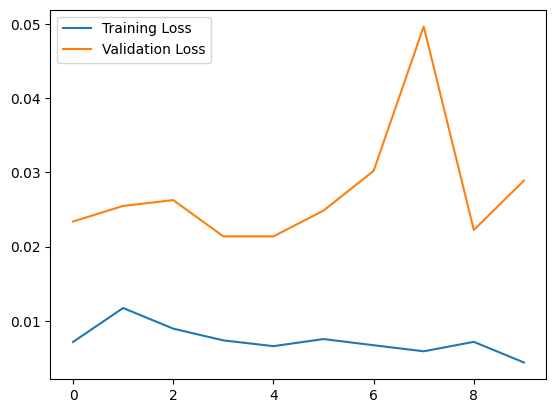

In [45]:
# fig 1-> Training and validation loss
sns.lineplot(x=range(epochs),y=train_loss_graph,label="Training Loss")
sns.lineplot(x=range(epochs),y=val_loss_graph,label="Validation Loss")
plt.show()

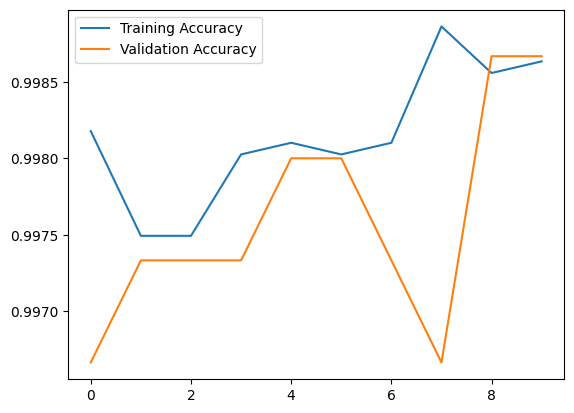

In [46]:
# fig2 -> Training and validation accurcay
sns.lineplot(x=range(epochs),y=train_acc_graph,label="Training Accuracy")
sns.lineplot(x=range(epochs),y=val_acc_graph,label="Validation Accuracy")
plt.show()

In [50]:

le_classes

[np.int64(0), np.int64(1), np.int64(2)]

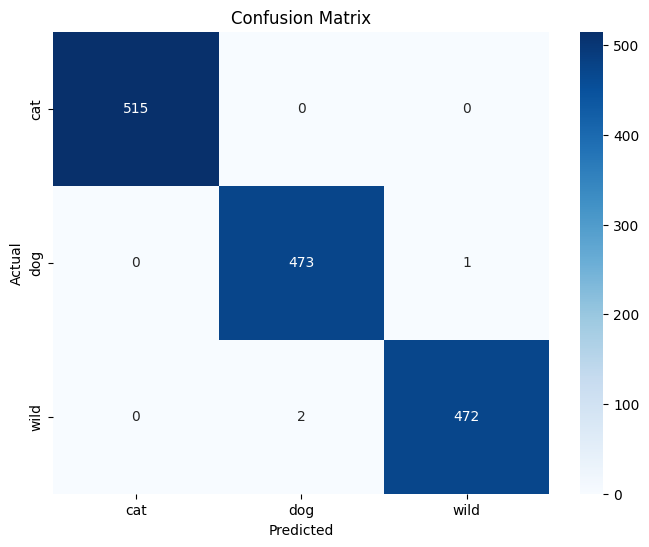

In [54]:
# Classification report
from sklearn.metrics import confusion_matrix, classification_report


class_names = ['cat', 'dog', 'wild']
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [55]:
print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

         cat       1.00      1.00      1.00       515
         dog       1.00      1.00      1.00       474
        wild       1.00      1.00      1.00       474

    accuracy                           1.00      1463
   macro avg       1.00      1.00      1.00      1463
weighted avg       1.00      1.00      1.00      1463



In [62]:
import os

# Save model weights
torch.save(model.state_dict(), 'cat_dog_wild_vgg16.pth')

# Download
from google.colab import files
files.download('cat_dog_wild_vgg16.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>